## Семинар 2: Value iteration

In [ ]:
# !pip install gym==0.22.0

### Выжимка из лекций

Q функция(Q value)
$$Q^\pi(s, a) = \mathbb{E}_\pi \left\{ G_t \mid s_t = s, a_t = a \right\} = \mathbb{E}_\pi \left\{ \sum_{k=0}^{\infty} \gamma^k r_{t+k+1} \mid s_t = s, a_t = a \right\}$$


V функция(V value)
$$V^\pi(s) = \mathbb{E}_\pi \left\{ G_t \mid s_t = s\right\} = \mathbb{E}_\pi \left\{ \sum_{k=0}^{\infty} \gamma^k r_{t+k+1} \mid s_t = s\right\}$$

Рассмотрим получение алгоритма Value Iteration:

Уравнение Белмана:
$V^\pi(s) = \sum_{a} \pi(a \mid s) \sum_{s'} P(s' \mid s, a) \left[ r(s, a, s') + \gamma V^\pi(s') \right]$


Принцип оптимальности Беллмана заключается в том, что на каждом шаге следует выбирать оптимальное управление в предположении об оптимальности всех последующих шагов. Другими словами, каково бы ни было состояние системы перед очередным шагом, нужно выбрать управление так, чтобы выигрыш на данном шаге плюс оптимальный выигрыш на всех последующих шагах был бы максимальным.

Уравнение оптимальности Беллмана:
$V^*(s) = \max_a \sum_{s'} P(s' \mid s, a) \left[ r(s, a, s') + \gamma V^*(s') \right]$

Формула для обновления V value через оптимальное уравнение белмана:
$$
$$
$V_{(i+1)}(s) = \max_a \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')]$
$$
$$

Для удобства расчетов обновление $V$ можно делать через $Q$ функцию:
$$
$$
$Q_i(s, a) = \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')]$
$$
$$
$V_{(i+1)}(s) = \max_a Q_i(s,a)$
$$
$$

Зададим напрямую модель MDP с картинки:
<img src="https://raw.githubusercontent.com/Tviskaron/mipt/master/2019/RL/02/mdp.png" caption="Марковский процесс принятия решений" style="width: 400px;">

In [1]:
# try:
#     import google.colab
#     COLAB = True
# except ModuleNotFoundError:
#     COLAB = False
#     pass

# if COLAB:
#     !wget https://raw.githubusercontent.com/Tviskaron/mipt/master/2019/RL/02/mdp.py

In [4]:
transition_probs = {
  's0':{
    'a0': {'s0': 0.5, 's2': 0.5},
    'a1': {'s2': 1}
  },
  's1':{
    'a0': {'s0': 0.7, 's1': 0.1, 's2': 0.2},
    'a1': {'s1': 0.95, 's2': 0.05}
  },
  's2':{
    'a0': {'s0': 0.4, 's2': 0.6},
    'a1': {'s0': 0.3, 's1': 0.3, 's2':0.4}
  }
}
rewards = {
  's1': {'a0': {'s0': +5}},
  's2': {'a1': {'s0': -1}}
}

from mdp import MDP
import numpy as np
mdp = MDP(transition_probs, rewards, initial_state='s0')

AttributeError: module 'numpy' has no attribute 'typeDict'

Теперь мы можем использовать это MDP, как и любое другое gym окружение:

In [ ]:
state = mdp.reset()
print('initial state =', state)
next_state, reward, done, info = mdp.step('a1')
print(f'next_state ={next_state}, reward = {reward}, done = {done}')

initial state = s0
next_state =s2, reward = 0.0, done = False


Также, помимо стандартных методов, есть дополнительные, которые пригодятся нам для реализации метода итерации по полезностям.

In [ ]:
print("all_states =", mdp.get_all_states())
print("possible_actions('s1') = ", mdp.get_possible_actions('s1'))
print("next_states('s1', 'a0') = ", mdp.get_next_states('s1', 'a0'))
print("reward('s1', 'a0', 's0') = ", mdp.get_reward('s1', 'a0', 's0'))
print("transition_prob('s1', 'a0', 's0') = ",
      mdp.get_transition_prob('s1', 'a0', 's0'))

all_states = ('s0', 's1', 's2')
possible_actions('s1') =  ('a0', 'a1')
next_states('s1', 'a0') =  {'s0': 0.7, 's1': 0.1, 's2': 0.2}
reward('s1', 'a0', 's0') =  5
transition_prob('s1', 'a0', 's0') =  0.7


### Задание 1

Теперь реализуем алгоритм итерации по полезностям, чтобы решить этот вручную заданный MDP. Псевдокод алгоритма:

---

`1.` Инициализируем $V_{(0)}(s)=0$, для всех $s$

`2.` For $i=0, 1, 2, \dots$

- For each s
$$
$$
  $ \quad V_{(i+1)}(s) = \max_a \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')]$

---

Вначале вычисляем оценку состояния-действия:
$$Q_i(s, a) = \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')]$$

In [ ]:
def get_action_value(mdp, state_values, state, action, gamma):
    """
      Вход: mdp(среда), state_values: dict{str:float}, state: str, action: str
    """
    """ Вычислеям Q(s,a) по формуле выше """
    # вычислеяем оценку состояния
    # Q =
    raise NotimplementedError

    return Q

In [ ]:
test_Vs = {s: i for i, s in enumerate(sorted(mdp.get_all_states()))}
assert np.isclose(get_action_value(mdp, test_Vs, 's2', 'a1', 0.9), 0.69)
assert np.isclose(get_action_value(mdp, test_Vs, 's1', 'a0', 0.9), 3.95)

Теперь оцениваем полезность самого состояния, для этого мы можем использовать предыдущий метод:

$$V_{(i+1)}(s) = \max_a \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')] = \max_a Q_i(s,a)$$

In [ ]:
def get_new_state_value(mdp, state_values, state, gamma):
    """ Считаем следующее V(s) по формуле выше."""
    if mdp.is_terminal(state):
        return 0
    # V =
    raise NotimplementedError

    return V

In [ ]:
test_Vs_copy = dict(test_Vs)
assert np.isclose(get_new_state_value(mdp, test_Vs, 's0', 0.9), 1.8)
assert np.isclose(get_new_state_value(mdp, test_Vs, 's2', 0.9), 1.08)
assert np.isclose(get_new_state_value(mdp, {'s0': -1e10, 's1': 0, 's2': -2e10}, 's0', 0.9), -13500000000.0), \
   "Убедитесь, что вы правильно обрабатываете отрицательные значения Q произвольной величины."
assert test_Vs == test_Vs_copy, "Убедитесь, что вы не изменяете state_values в функции get_new_state_value"

Теперь создаем основной цикл Policy Iteration с критерием остановки, который проверяет насколько изменилась V функция.

In [ ]:
def value_iteration(mdp, state_values=None,
          gamma = 0.9, num_iter = 1000, min_difference = 1e-5):
    """ выполняет num_iter шагов итерации по значениям"""
    # инициализируем V(s)
    state_values = state_values or \
      {s : 0 for s in mdp.get_all_states()}

    for i in range(num_iter):
        # Вычисляем новые полезности состояний,
        # используя функции, определенные выше.
        # Должен получиться словарь {s: new_V(s)}
        # new_state_values =
        raise NotimplementedError

        assert isinstance(new_state_values, dict)

        # Считаем разницу
        diff = max(abs(new_state_values[s] - state_values[s]) for s in mdp.get_all_states())

        print("iter %4i | diff: %6.5f | V(start): %.3f "%
          (i, diff, new_state_values[mdp._initial_state]))

        state_values = new_state_values
        if diff < min_difference:
            print("Принято! Алгоритм сходится!")
            break

    return state_values

state_values = value_iteration(mdp,
        num_iter = 100, min_difference = 0.001)

iter    0 | diff: 3.50000 | V(start): 0.000 
iter    1 | diff: 0.64500 | V(start): 0.000 
iter    2 | diff: 0.58050 | V(start): 0.581 
iter    3 | diff: 0.43582 | V(start): 0.866 
iter    4 | diff: 0.30634 | V(start): 1.145 
iter    5 | diff: 0.27571 | V(start): 1.421 
iter    6 | diff: 0.24347 | V(start): 1.655 
iter    7 | diff: 0.21419 | V(start): 1.868 
iter    8 | diff: 0.19277 | V(start): 2.061 
iter    9 | diff: 0.17327 | V(start): 2.233 
iter   10 | diff: 0.15569 | V(start): 2.389 
iter   11 | diff: 0.14012 | V(start): 2.529 
iter   12 | diff: 0.12610 | V(start): 2.655 
iter   13 | diff: 0.11348 | V(start): 2.769 
iter   14 | diff: 0.10213 | V(start): 2.871 
iter   15 | diff: 0.09192 | V(start): 2.963 
iter   16 | diff: 0.08272 | V(start): 3.045 
iter   17 | diff: 0.07445 | V(start): 3.120 
iter   18 | diff: 0.06701 | V(start): 3.187 
iter   19 | diff: 0.06031 | V(start): 3.247 
iter   20 | diff: 0.05428 | V(start): 3.301 
iter   21 | diff: 0.04885 | V(start): 3.350 
iter   22 

In [ ]:
print("Final state values:", state_values)

assert abs(state_values['s0'] - 3.781) < 0.01
assert abs(state_values['s1'] - 7.294) < 0.01
assert abs(state_values['s2'] - 4.202) < 0.01

Final state values: {'s0': 3.7810348735476405, 's1': 7.294006423867229, 's2': 4.202140275227048}


По найденным полезностям и зная модель переходов легко найти оптимальную стратегию:
$$\pi^*(s) = argmax_a \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')] = argmax_a Q_i(s,a)$$

In [ ]:
def get_optimal_action(mdp, state_values, state,
                       gamma=0.9):
    """ Находим оптимальное действие, используя формулу выше. """
    if mdp.is_terminal(state): return None

    actions = mdp.get_possible_actions(state)
    # выбираем лучшее действие
    # i =
    raise NotimplementedError

    return actions[i]

In [ ]:
assert get_optimal_action(mdp, state_values, 's0', 0.9) == 'a1'
assert get_optimal_action(mdp, state_values, 's1', 0.9) == 'a0'
assert get_optimal_action(mdp, state_values, 's2', 0.9) == 'a1'

assert get_optimal_action(mdp, {'s0': -1e10, 's1': 0, 's2': -2e10}, 's0', 0.9) == 'a0', \
    "Убедитесь, что вы правильно обрабатываете отрицательные значения Q произвольной величины."
assert get_optimal_action(mdp, {'s0': -2e10, 's1': 0, 's2': -1e10}, 's0', 0.9) == 'a1', \
    "Убедитесь, что вы правильно обрабатываете отрицательные значения Q произвольной величины."

In [ ]:
# Проверим среднее вознаграждение агента

s = mdp.reset()
rewards = []
for _ in range(10000):
    s, r, done, _ = mdp.step(get_optimal_action(mdp, state_values, s, 0.9))
    rewards.append(r)

print("average reward: ", np.mean(rewards))

assert(0.40 < np.mean(rewards) < 0.55)

average reward:  0.4506


### Задание 2

Теперь проверим работу Value Iteration на классической задаче FrozenLake.
https://gymnasium.farama.org/environments/toy_text/frozen_lake/

In [ ]:
from mdp import FrozenLakeEnv
mdp = FrozenLakeEnv(slip_chance=0)

mdp.render()
state_values = value_iteration(mdp)

*FFF
FHFH
FFFH
HFFG

iter    0 | diff: 1.00000 | V(start): 0.000 
iter    1 | diff: 0.90000 | V(start): 0.000 
iter    2 | diff: 0.81000 | V(start): 0.000 
iter    3 | diff: 0.72900 | V(start): 0.000 
iter    4 | diff: 0.65610 | V(start): 0.000 
iter    5 | diff: 0.59049 | V(start): 0.590 
iter    6 | diff: 0.00000 | V(start): 0.590 
Принято! Алгоритм сходится!


Визуализируем V функцию для всех состояний.

In [ ]:
def draw_policy(mdp, state_values, gamma=0.9):
    """функция визуализации стратегии"""
    plt.figure(figsize=(3, 3))
    h, w = mdp.desc.shape
    states = sorted(mdp.get_all_states())
    V = np.array([state_values[s] for s in states])
    Pi = {
        s: get_optimal_action(mdp, state_values, s, gamma)
        for s in states}
    plt.imshow(V.reshape(w, h),
               cmap='gray', interpolation='none',
               clim=(0, 1))
    ax = plt.gca()
    ax.set_xticks(np.arange(h) - .5)
    ax.set_yticks(np.arange(w) - .5)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    Y, X = np.mgrid[0:4, 0:4]
    a2uv = {'left': (-1, 0), 'down': (0, -1),
            'right': (1, 0), 'up': (-1, 0)}
    for y in range(h):
        for x in range(w):
            plt.text(x, y, str(mdp.desc[y, x].item()),
                     color='g', size=12,
                     verticalalignment='center',
                     horizontalalignment='center',
                     fontweight='bold')
            a = Pi[y, x]
            if a is None: continue
            u, v = a2uv[a]
            plt.arrow(x, y, u * .3, -v * .3,
                      color='m', head_width=0.1,
                      head_length=0.1)
    plt.grid(color='b', lw=2, ls='-')
    plt.show()


after iteration 29
iter    0 | diff: 0.00000 | V(start): 0.198 
Принято! Алгоритм сходится!


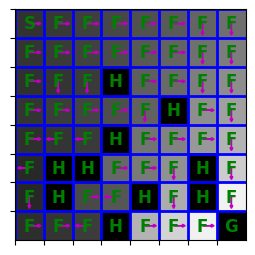

In [ ]:
from IPython.display import clear_output
from time import sleep
import matplotlib.pyplot as plt
%matplotlib inline
mdp = FrozenLakeEnv(map_name='8x8',slip_chance=0.1)
state_values = {s : 0 for s in mdp.get_all_states()}

for i in range(30):
    clear_output(True)
    print("after iteration %i"%i)
    state_values = value_iteration(mdp,
                            state_values, num_iter=1)
    draw_policy(mdp, state_values)
    sleep(0.5)

Выведем траекторию оптимальной стратегии:

In [ ]:
s = mdp.reset()
mdp.render()
for t in range(100):
    a = get_optimal_action(mdp, state_values, s, 0.9)
    print(a, end='\n\n')
    s, r, done, _ = mdp.step(a)
    mdp.render()
    if done:
        break

*FFF
FHFH
FFFH
HFFG

down

SFFF
*HFH
FFFH
HFFG

down

SFFF
FHFH
*FFH
HFFG

right

SFFF
FHFH
F*FH
HFFG

down

SFFF
FHFH
FFFH
H*FG

right

SFFF
FHFH
FFFH
HF*G

right

SFFF
FHFH
FFFH
HFF*



Обучаем и Выводим траекторию на более сложном варианте окружения:

In [ ]:
mdp = FrozenLakeEnv(slip_chance=0.2, map_name='8x8')

# Обучить
raise NotimplementedError


iter    0 | diff: 0.80000 | V(start): 0.000 
iter    1 | diff: 0.57600 | V(start): 0.000 
iter    2 | diff: 0.41472 | V(start): 0.000 
iter    3 | diff: 0.29860 | V(start): 0.000 
iter    4 | diff: 0.24186 | V(start): 0.000 
iter    5 | diff: 0.19349 | V(start): 0.000 
iter    6 | diff: 0.15325 | V(start): 0.000 
iter    7 | diff: 0.12288 | V(start): 0.000 
iter    8 | diff: 0.09930 | V(start): 0.000 
iter    9 | diff: 0.08037 | V(start): 0.000 
iter   10 | diff: 0.06426 | V(start): 0.000 
iter   11 | diff: 0.05129 | V(start): 0.000 
iter   12 | diff: 0.04330 | V(start): 0.000 
iter   13 | diff: 0.03802 | V(start): 0.033 
iter   14 | diff: 0.03332 | V(start): 0.058 
iter   15 | diff: 0.02910 | V(start): 0.087 
iter   16 | diff: 0.01855 | V(start): 0.106 
iter   17 | diff: 0.01403 | V(start): 0.120 
iter   18 | diff: 0.00810 | V(start): 0.128 
iter   19 | diff: 0.00555 | V(start): 0.133 
iter   20 | diff: 0.00321 | V(start): 0.137 
iter   21 | diff: 0.00247 | V(start): 0.138 
iter   22 

In [ ]:
# Вывести траекторию
raise NotimplementedError

*FFFFFFF
FFFFFFFF
FFFHFFFF
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG

right

S*FFFFFF
FFFFFFFF
FFFHFFFF
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG

right

S*FFFFFF
FFFFFFFF
FFFHFFFF
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG

right

S*FFFFFF
FFFFFFFF
FFFHFFFF
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG

right

SF*FFFFF
FFFFFFFF
FFFHFFFF
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG

right

SFF*FFFF
FFFFFFFF
FFFHFFFF
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG

right

SFFF*FFF
FFFFFFFF
FFFHFFFF
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG

right

SFFFF*FF
FFFFFFFF
FFFHFFFF
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG

right

SFFFFF*F
FFFFFFFF
FFFHFFFF
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG

down

SFFFFFFF
FFFFFF*F
FFFHFFFF
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG

down

SFFFFFFF
FFFFFFFF
FFFHFF*F
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG

right

SFFFFFFF
FFFFFFFF
FFFHFFF*
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG

down

SFFFFFFF
FFFFFFFF
FFFHFFFF
FFFFFHF*
FFFHFFF